In [1]:
import pandas as pd
import numpy as np
import random
import time

# Zeros reais de funções reais

## Letra A

### Algortimos usados

#### Bissecção

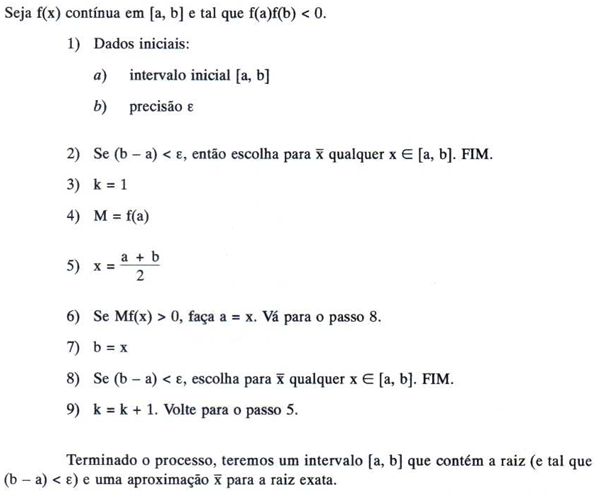

In [2]:
def bissection(function: callable, interval: tuple, precision: float):
    operations = 0
    logic_decisions = 0
    evaluations = 0

    a, b = interval # 1a
    epsilon = precision # 1b

    operations += 1
    logic_decisions += 1
    if (b - a) < epsilon: # 2
        return random.choice([a, b]), operations, logic_decisions, evaluations, 0

    k = 1 # 3
    
    evaluations +=1
    m = function(a) # 4

    while True:
        operations += 2
        x = (a + b) / 2 # 5

        logic_decisions += 1
        evaluations += 1
        operations += 1
        if m * function(x) > 0: # 6
            a = x   # 6
        else:
            b = x # 7

        operations += 1
        logic_decisions += 1
        if (b - a) < epsilon: # 8
            return random.choice([a, b]), operations, logic_decisions, evaluations, k # 8

        operations += 1
        k +=1 # 9

#### Posição Falsa

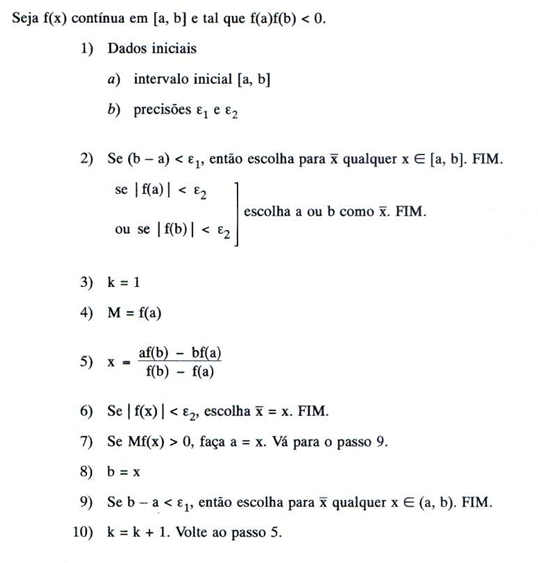

In [3]:
def false_position(function: callable, interval: tuple, precisions: tuple):
    operations = 0
    logic_decisions = 0
    evaluations = 0

    a, b = interval # 1a
    epsilon1, epsilon2 = precisions # 1b

    operations += 1
    logic_decisions += 1
    if (b - a) < epsilon1: # 2
        return random.choice([a, b]), operations, logic_decisions, evaluations, 0
    
    logic_decisions += 1
    operations += 1
    if abs(function(a)) < epsilon2: # 2
        return a, operations, logic_decisions, evaluations, 0

    logic_decisions += 1
    operations += 1
    if abs(function(b)) < epsilon2: # 2
        return b, operations, logic_decisions, evaluations, 0

    k = 1 # 3

    evaluations += 1
    m = function(a) # 4

    while True:
        operations += 5
        evaluations += 4
        x = (a * function(b) - b * function(a)) / (function(b) -  function(a)) # 5

        logic_decisions += 1
        evaluations += 1
        operations += 1
        if abs(function(x)) < epsilon2: # 6
            return x, operations, logic_decisions, evaluations, k

        logic_decisions += 1
        operations += 1
        evaluations += 1
        if m * function(x) > 0: # 7
            a = x
        else: # 8
            b = x

        logic_decisions += 1
        operations += 1
        if (b - a) < epsilon1: # 9
            return random.choice([a, b]), operations, logic_decisions, evaluations, k 
        
        operations += 1
        k +=1 # 10

#### Método do Ponto Fixo

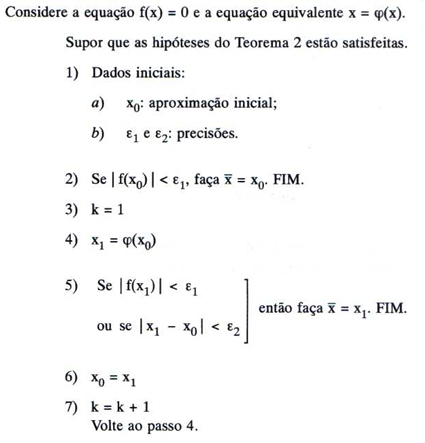

In [4]:
def fixed_point_method(function: callable, phi: callable, initial_guess : float, precisions: tuple):
    operations = 0
    logic_decisions = 0
    evaluations = 0

    x0 = initial_guess # 1a
    epsilon1, epsilon2 = precisions # 1b
    
    operations += 1
    logic_decisions += 1
    evaluations += 1
    if abs(function(x0)) < epsilon1: # 2
        return x0, operations, logic_decisions, evaluations, 0
    
    k = 1 # 3

    while True:
        evaluations += 1
        x1 = phi(x0) # 4

        operations += 3
        logic_decisions += 2
        evaluations += 1
        if abs(function(x1)) < epsilon1 or abs(x1 - x0) < epsilon2: # 5
            return x1, operations, logic_decisions, evaluations, k

        x0 = x1 # 6

        operations += 1
        k += 1 # 7

#### Newton

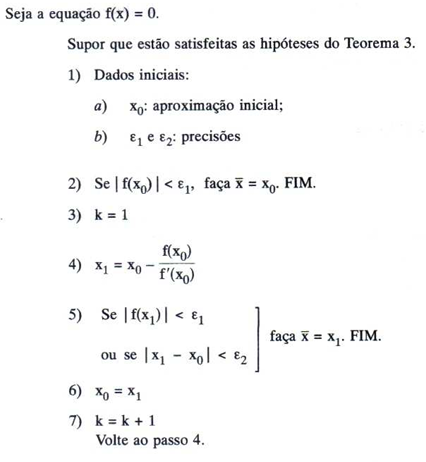

In [5]:
def newton(function: callable, derivate: callable, initial_guess: float, precisions: tuple):
    operations = 0
    logic_decisions = 0
    evaluations = 0

    x0 = initial_guess # 1a
    epsilon1, epsilon2 = precisions # 1b

    operations += 1
    logic_decisions += 1
    evaluations += 1
    if abs(function(x0)) < epsilon1:
        return x0, operations, logic_decisions, evaluations, 0

    k = 1

    while True:
        operations += 2
        evaluations += 2
        x1 = x0 - function(x0)/derivate(x0) # 4

        logic_decisions += 2
        operations += 3
        evaluations += 1
        if abs(function(x1)) < epsilon1 or abs(x1 - x0) < epsilon2: # 5
            return x1, operations, logic_decisions, evaluations, k

        x0 = x1 #6

        operations += 1
        k += 1 # 7

#### Secante
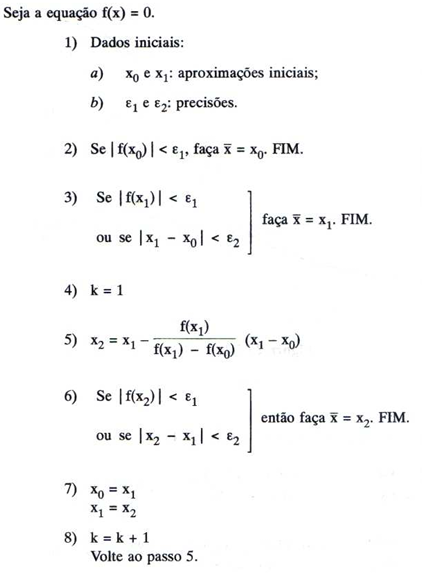

In [6]:
def secant(function: callable, initial_guesses: tuple, precisions: tuple):
    operations = 0
    logic_decisions = 0
    evaluations = 0

    x0, x1 = initial_guesses # 1a
    epsilon1, epsilon2 = precisions # 1b

    operations += 1
    logic_decisions += 1
    evaluations += 1
    if abs(function(x0)) < epsilon1: # 2
        return x0, operations, logic_decisions, evaluations, 0

    operations += 3
    logic_decisions += 2
    evaluations += 1
    if abs(function(x1)) < epsilon1 or abs(x1 - x0) < epsilon2: # 3
            return x1, operations, logic_decisions, evaluations, 0

    k = 1 # 4

    while True:
        operations += 5
        evaluations += 3
        x2 = x1 - function(x1)/(function(x1) - function(x0)) * (x1 - x0) # 5

        operations += 3
        logic_decisions += 2
        evaluations += 1
        if abs(function(x2)) < epsilon1 or abs(x2 - x1) < epsilon2: # 6
            return x2, operations, logic_decisions, evaluations, k

        x0, x1 = x1, x2 # 7

        operations += 1
        k += 1 # 8

### Conceitos

#### Método da Bissecção

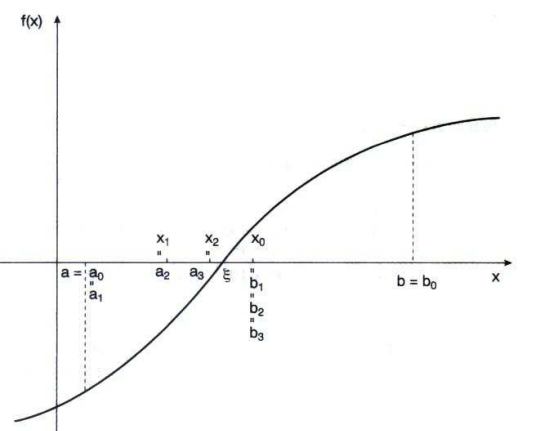

Este método é baseado no Teorema do Valor Intermediário. Se uma função contínua muda de sinal em um intervalo $[a, b]$, ou seja, $f(a) \cdot f(b) < 0$, então existe pelo menos uma raiz nesse intervalo. O algoritmo divide o intervalo ao meio repetidamente e em cada passo, verifica-se em qual subintervalo a troca de sinal ocorre. Se houver troca de sinal a convergência é garantida, mas essa convergência é muito lenta.

O novo ponto aproximado é a média simples:

$$x_{k+1} = \frac{a_k + b_k}{2}$$


#### Método da Posição Falsa

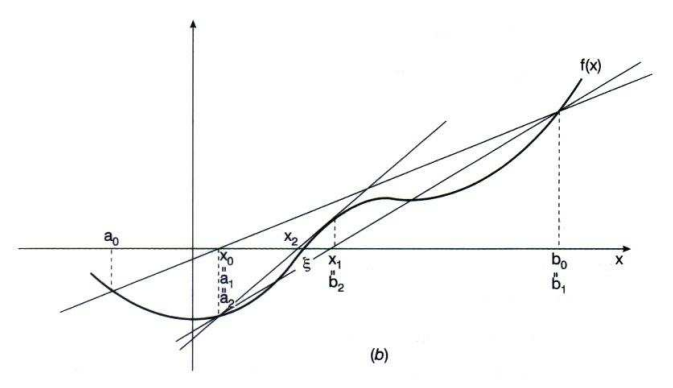

É considerado uma melhoria da Bissecção. Traça-se uma reta secante unindo os pontos $(a, f(a))$ e $(b, f(b))$. O ponto onde esta reta cruza o eixo $x$ é a nova aproximação. Para escolher o novo intervalo, verifica-se se $f(a) \cdot f(x_r) < 0$ ou $f(b) \cdot f(x_r) < 0$. Geralmente converge mais rápido que a Bissecção, mas ainda pode ser lento se a função for muito curva em um dos lados.

Sua fórmula é uma média ponderada:

$$x_{k+1} = \frac{a_k f(b_k) - b_k f(a_k)}{f(b_k) - f(a_k)}$$

#### Método do Ponto Fixo

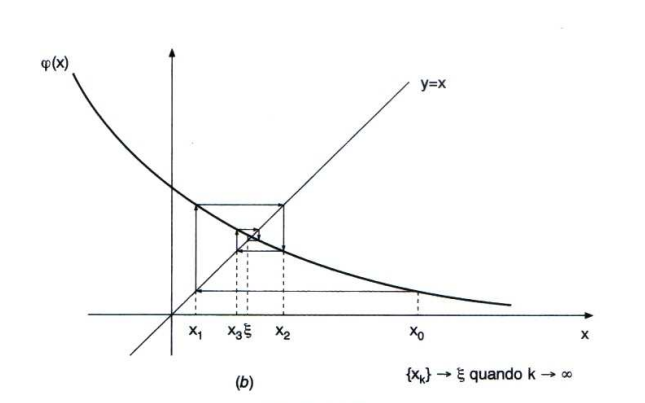

Este método reescreve a equação $f(x) = 0$ na forma $x = \phi(x)$. A raiz da função original é o "ponto fixo" onde a curva $\phi(x)$ cruza a reta $y = x$. Chuta-se um valor inicial $x_0$ e coloca-o na função $\phi(x)$ para obter o próximo valor. Esse resultado é colocado novamente na função e sucessivamente. A convergência não é garantida, depende da derivada de $\phi(x)$, que deve ser $|\phi'(x)| < 1$ perto da raiz.

Sua fórmula se dá por:

$$x_{k+1} = \phi(x_k)$$

#### Método de Newton

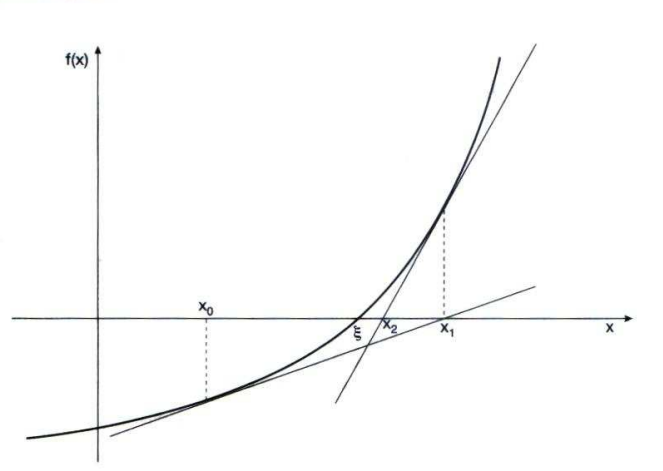

Frequentemente considerado o melhor método. Ele utiliza a derivada da função para "prever" onde a raiz está. A partir de um chute inicial $x_k$, traça-se a reta tangente à curva nesse ponto. Onde a tangente cruza o eixo $x$ torna-se o novo $x_{k+1}$. Sua convergência é quadrática perto da raiz, mas exige o cálculo da derivada $f'(x)$ e pode falhar se $f'(x_k) \approx 0$

Sua fórmula é:

$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$$

#### Método da Secante

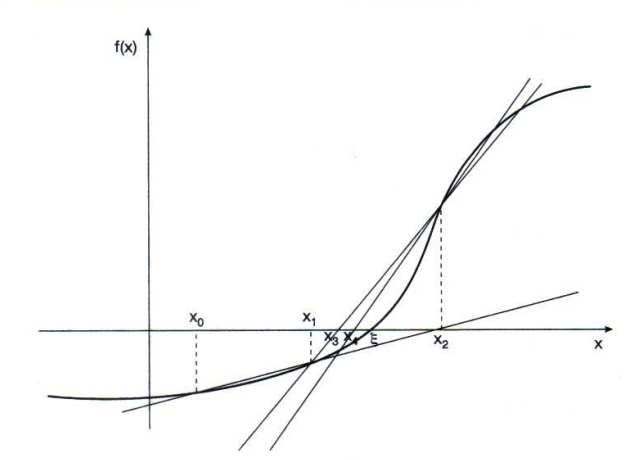

O método da Secante é uma variação do método de Newton para quando calcular a derivada $f'(x)$ é muito difícil ou custoso computacionalmente. Em vez de usar a derivada exata, ele aproxima a derivada usando uma reta secante que passa pelos dois últimos pontos calculados ($x_k$ e $x_{k-1}$). Esse método requer dois chutes iniciais. Converge mais rápido que a Bissecção e a Posição Falsa, mas um pouco mais devagar que Newton. Não garante convergência se o chute for ruim.

Sua fórmula é:

$$x_{k+1} = x_k - f(x_k) \cdot \frac{x_k - x_{k-1}}{f(x_k) - f(x_{k-1})}$$

### Exemplos

In [14]:
def create_table(f: callable, functions: tuple, root: float):
    results = {}
    
    for function_name, function, data_initial in functions:
        result, operations, logic_decisions, evaluations, iterations = function
        f_result = f(result)
        error = abs(root - result)

        results[function_name] = {
            'Dados Iniciais': data_initial,
            'X aproximado': result,
            'f(x _aproximado)': f'{f_result:8}',
            'Erro em x': f'{error:8}',
            'Número de Iterações': iterations,
            'Número de Avaliações': evaluations,
            'Número de Operações': operations,
            'Número de Decisões Lógicas': logic_decisions,
            
        }

    return pd.DataFrame(results)

#### Exemplo 18

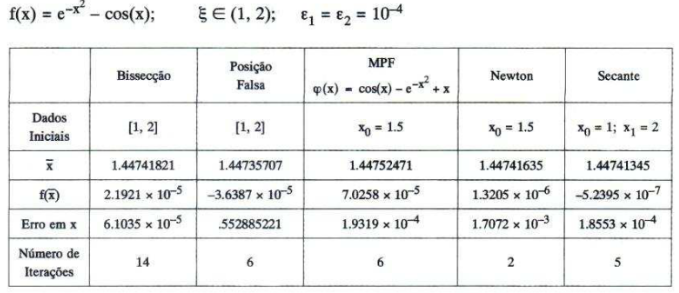

In [15]:
def f(x):
    return np.exp(-x ** 2) - np.cos(x)

def df(x):
    return -2 * x * np.exp(-x**2) + np.sin(x)

def phi(x):
    return np.cos(x) - np.exp(-x ** 2) + x

e1 = e2 = 10 ** -4
interval = (1, 2)
root = 1.44741427112
mpf_x = newton_x = 1.5
secant_x = interval

functions = [
    ('Bissecção', bissection(f, interval, e1), interval),
    ('Posição Falsa', false_position(f, interval, (e1, e2)), interval),
    ('MPF', fixed_point_method(f, phi, mpf_x, (e1, e2)), mpf_x),
    ('Newton', newton(f, df, newton_x, (e1, e2)), newton_x),
    ('Secante', secant(f, secant_x, (e1, e2)), secant_x)
]
create_table(f, functions, root)


,Bissecção,Posição Falsa,MPF,Newton,Secante
Dados Iniciais,"(1, 2)","(1, 2)",1.5,1.5,"(1, 2)"
X aproximado,1.447388,1.447357,1.447525,1.447416,1.447413
f(x _aproximado),-1.6905558310159607e-05,-3.638758569463052e-05,7.025777685441825e-05,1.3204357450918858e-06,-5.242249916104225e-07
Erro em x,2.657580749998445e-05,5.7203319429710575e-05,0.00011043645378272515,2.0758936110087944e-06,8.239041318081064e-07
Número de Iterações,14,6,6,2,5
Número de Avaliações,15,36,13,7,22
Número de Operações,70,54,24,12,48
Número de Decisões Lógicas,29,19,13,5,13


Todos os algoritmos convergiram pra raíz. O método de Newton convergiu mais rápido e o da bisseção, mais lento e com maior número de operações aritméticas e decisões lógicas, como o esperado. Em questão de avaliação, apesar do Método da Posição Falsa apresentar uma convergência rápida, ela foi computacionalmente custosa. O Método de Newton apresentou a menor quantidade de decisões lógicas.

#### Exemplo 19

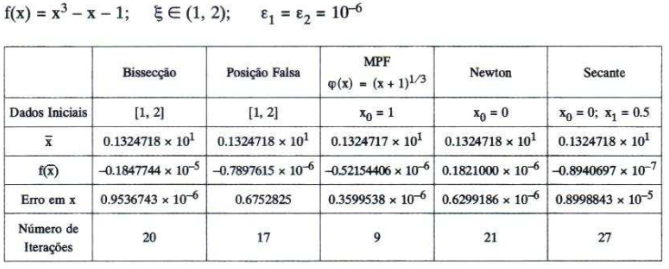

In [18]:
def f(x):
    return x ** 3 - x - 1

def df(x):
    return 3 * x ** 2 - 1

def phi(x):
    return (x + 1) ** (1 / 3)

e1 = e2 = 10 ** -6
interval = (1, 2)
root = 1.32471795
mpf_x = 1
newton_x = 0
secant_x = (0, 0.5)

functions = [
    ('Bissecção', bissection(f, interval, e1), interval),
    ('Posição Falsa', false_position(f, interval, (e1, e2)), interval),
    ('MPF', fixed_point_method(f, phi, mpf_x, (e1, e2)), mpf_x),
    ('Newton', newton(f, df, newton_x, (e1, e2)), newton_x),
    ('Secante', secant(f, secant_x, (e1, e2)), secant_x)
]

create_table(f, functions, root)

,Bissecção,Posição Falsa,MPF,Newton,Secante
Dados Iniciais,"(1, 2)","(1, 2)",1,0,"(0, 0.5)"
X aproximado,1.324718,1.324718,1.324718,1.324718,1.324718
f(x _aproximado),2.209494846194815e-06,-8.290661304144464e-07,-4.737264742704639e-07,2.7471358521324873e-12,-4.3405755212333474e-08
Erro em x,5.253417969530716e-07,1.871603247938225e-07,1.0383785431500314e-07,7.245390287735631e-09,2.933329135146323e-09
Número de Iterações,20,17,9,21,26
Número de Avaliações,21,102,19,64,106
Número de Operações,100,153,36,126,237
Número de Decisões Lógicas,41,52,19,43,55


Todos os algorítmos convergiram para a raiz. Nesse caso, o método de Newton e da Secante apresentaram um resultado (número de iterações) pior que o da Bissecção, o que indica que o chute inicial foi ruim. Nota-se que o método da Posição Falsa e da Secante foram computacionalmente custosos, com mais de 100 avaliações. O MPF saiu-se melhor nesse exemplo, liderando em: número de iterações, avaliações, operações e decisões lógicas. 

#### Exemplo 20

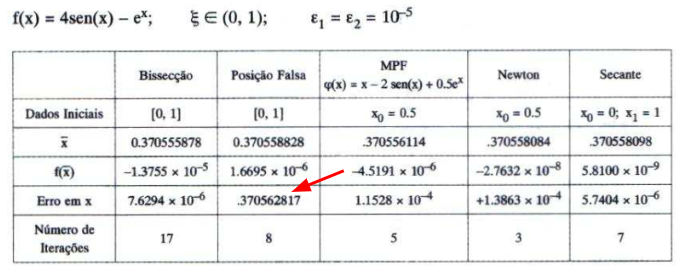

In [20]:
def f(x):
    return 4 * np.sin(x) - np.exp(x)

def df(x):
    return 4 * np.cos(x) - np.e ** x

def phi(x):
    return x - 2 * np.sin(x) + 0.5 * np.exp(x)

e1 = e2 = 10 ** - 5
interval = (0, 1)
root = 0.3705580959
mpf_x = newton_x = 0.5
secant_x = interval

functions = [
    ('Bissecção', bissection(f, interval, e1), interval),
    ('Posição Falsa', false_position(f, interval, (e1, e2)), interval),
    ('MPF', fixed_point_method(f, phi, mpf_x, (e1, e2)), mpf_x),
    ('Newton', newton(f, df, newton_x, (e1, e2)), newton_x),
    ('Secante', secant(f, secant_x, (e1, e2)), secant_x)
]

create_table(f, functions, root)

,Bissecção,Posição Falsa,MPF,Newton,Secante
Dados Iniciais,"(0, 1)","(0, 1)",0.5,0.5,"(0, 1)"
X aproximado,0.37056,0.370559,0.370556,0.370558,0.370558
f(x _aproximado),3.639752024442444e-06,1.669806334314572e-06,-4.51936095435812e-06,-2.7834957228023427e-08,5.260490487657421e-09
Erro em x,1.5964828125047958e-06,7.324546239528829e-07,1.9821394228181077e-06,1.2138711036335792e-08,2.377099073136435e-09
Número de Iterações,17,8,5,3,7
Número de Avaliações,18,48,11,10,30
Número de Operações,85,72,20,18,66
Número de Decisões Lógicas,35,25,11,7,17


Todos os algortimos convergiram para a raíz. Nesse exemplo, o método Newton volta a mostrar um bom resultado, indicando um bom chute inicial. Nota-se que o método da Posição Falsa obteve o maior número de avaliações.

#### Exemplo 21

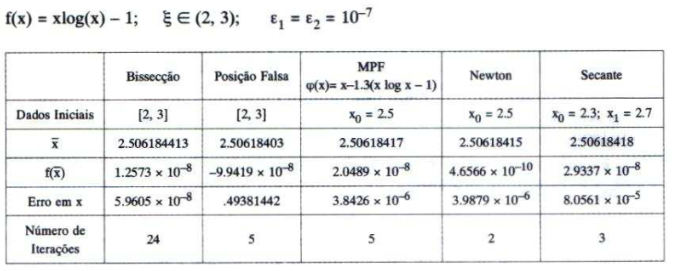

In [22]:
def f(x):
    return x * np.log10(x) - 1

def df(x):
    return x * np.log10(x) - (1 / np.log(10))

def phi(x):
    return x - 1.3 * (x * np.log10(x) - 1)

e1 = e2 = 10 ** - 7
interval = (2, 3)
root = 2.506184
mpf_x = newton_x = 2.5
secant_x = (2.3, 2.7)

functions = [
    ('Bissecção', bissection(f, interval, e1), interval),
    ('Posição Falsa', false_position(f, interval, (e1, e2)), interval),
    ('MPF', fixed_point_method(f, phi, mpf_x, (e1, e2)), mpf_x),
    ('Newton', newton(f, df, newton_x, (e1, e2)), newton_x),
    ('Secante', secant(f, secant_x, (e1, e2)), secant_x)
]

create_table(f, functions, root)

,Bissecção,Posição Falsa,MPF,Newton,Secante
Dados Iniciais,"(2, 3)","(2, 3)",2.5,2.5,"(2.3, 2.7)"
X aproximado,2.506184,2.506184,2.506184,2.506184,2.506184
f(x _aproximado),-3.7068876412860163e-08,-9.927991884151055e-08,2.0508265752283705e-08,6.968553689645773e-08,2.9152571690005402e-08
Erro em x,1.0110473613877957e-07,2.6449165968500665e-08,1.7019945186547147e-07,2.2921400910647094e-07,1.805729410442325e-07
Número de Iterações,24,5,5,15,3
Número de Avaliações,25,30,11,46,14
Número de Operações,120,45,20,90,30
Número de Decisões Lógicas,49,16,11,31,9


Todos os algoritmos convergiram para a raíz. Nota-se que nessa função, o método Newton obteve um péssimo resultado, com 15 iterações para convergir. O método da Secante mostrou-se mais eficaz que os demais métodos, com apenas 3 iterações. 

#### Exemplo 22

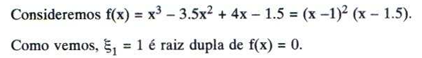

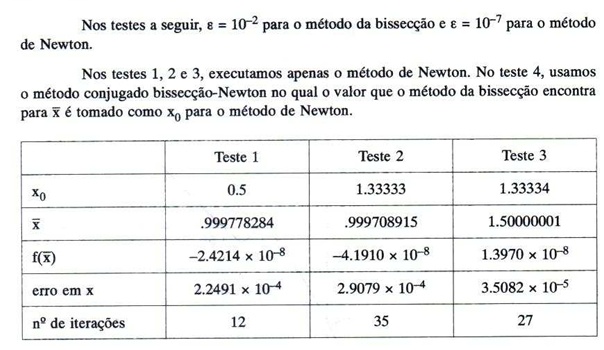

In [23]:
def newton_tests_table(f: callable, functions: tuple, roots: tuple):
    results = {}
    
    for function_name, function, data_initial in functions:
        result, operations, logic_decisions, evaluations, iterations = function
        f_result = f(result)
        
        if function_name == 'Teste 3':
            error = abs(roots[1] - result)
        else:
            error = abs(roots[0] - result)

        results[function_name] = {
            'Dados Iniciais': data_initial,
            'X aproximado': result,
            'f(x _aproximado)': f'{f_result:8}',
            'Erro em x': f'{error:8}',
            'Número de Iterações': iterations,
            'Número de Avaliações': evaluations,
            'Número de Operações': operations,
            'Número de Decisões Lógicas': logic_decisions, 
        }

    return pd.DataFrame(results)

In [24]:
def f(x):
    return x ** 3 - 3.5 * x ** 2 + 4 * x - 1.5

def df(x):
    return 3 * x ** 2 - 7 * x + 4

e1 = e2 = 10 ** - 7
root1 = 1
root2 = 1.5
initial_newton_guess1 = 0.5
initial_newton_guess2 = 1.33333
initial_newton_guess3 = 1.33334

newton_tests = [
    ('Teste 1', newton(f, df, initial_newton_guess1, (e1, e2)), initial_newton_guess1),
    ('Teste 2', newton(f, df, initial_newton_guess2, (e1, e2)), initial_newton_guess2),
    ('Teste 3', newton(f, df, initial_newton_guess3, (e1, e2)), initial_newton_guess3),
]

newton_tests_table(f, newton_tests, (root1, root2))

,Teste 1,Teste 2,Teste 3
Dados Iniciais,0.5,1.33333,1.33334
X aproximado,0.999553,0.999709,1.5
f(x _aproximado),-9.9935162811704e-08,-4.236363260190501e-08,1.2241256897027597e-09
Erro em x,0.0004468689436755158,0.0002909948172669097,4.896508754015372e-09
Número de Iterações,11,35,27
Número de Avaliações,34,106,82
Número de Operações,66,210,162
Número de Decisões Lógicas,23,71,55


Nesses testes, foram utilizados apenas o método de Newton. Todos convergiram para raíz com uma pequena margem de erro. Note que no teste 2, o número de iterações, avaliações e decisões lógicas foram maiores, indicando um péssimo chute. Apesar do chute do teste 3 ter sido parecido com o do teste 2, apresentou um melhor resultado e a raíz exata da função. O teste 1, apesar de não ter se aproximado tanto da raiz em comparação ao teste 2, apresentou o melhor desempenho entre os 3.

## Letra B

### Algoritmos Usados

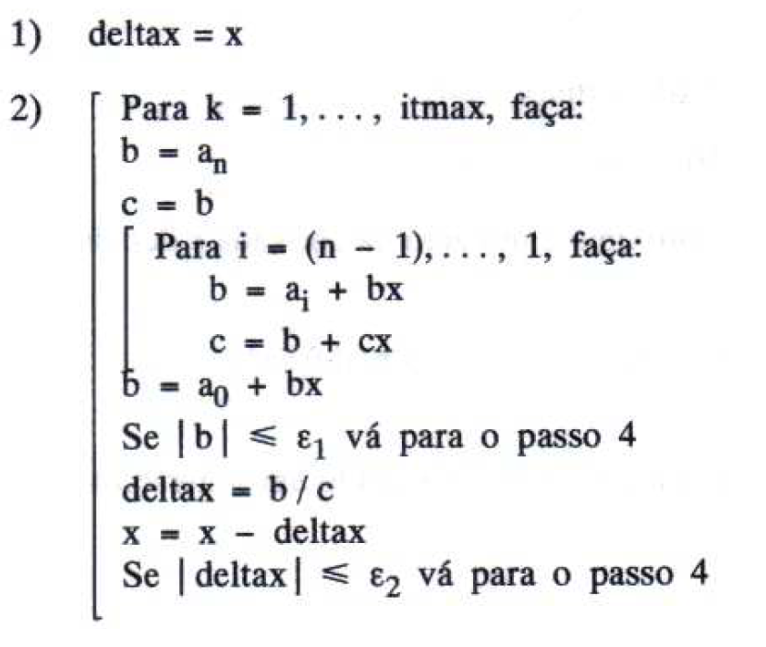

Método de Newton para funções polinomais.

In [41]:
def polynomial_newton(coefficients : tuple, initial_guess : float, precisions : tuple, it_max : int):
    n = len(coefficients) - 1
    deltax = initial_guess
    x = initial_guess
    epsilon1, epsilon2 = precisions

    start_time = time.perf_counter_ns()
    time_iteration = 0

    for k in range(it_max):
        start_it = time.perf_counter_ns()
        b = coefficients[n]
        c = b
        
        for i in range(n - 1, -1, -1): 
            b = coefficients[i] + b * x
            c = b + c * x
            
        b = coefficients[0] + b * x
        
        if abs(b) <= epsilon1:
            end_time = time.perf_counter_ns()
            time_iteration += end_time - start_it
            return x, k + 1, end_time - start_time, time_iteration
            
        deltax = b / c
        x = x - deltax
        
        if abs(deltax) <= epsilon2:
            end_time = time.perf_counter_ns()
            time_iteration += end_time - start_it
            return x, k + 1, end_time - start_time, time_iteration
        
    end_time = time.perf_counter_ns()
    return f"Não houve convergência com {it_max} iterações", it_max, end_time - start_time, time_iteration

Método da Secante adaptada a partir do método anterior

In [42]:
def secant_adapted(coefficients: tuple, initial_guesses: tuple, precisions: tuple, it_max: int):
    n = len(coefficients) - 1
    x0, x1 = initial_guesses
    epsilon1, epsilon2 = precisions
    start_time = time.perf_counter_ns()
    time_iteration = 0

    b0 = coefficients[n]
    for i in range(n - 1, -1, -1):
        b0 = coefficients[i] + b0 * x0

    b1 = coefficients[n]
    for i in range(n - 1, -1, -1):
        b1 = coefficients[i] + b1 * x1

    if abs(b0) < epsilon1:
        end_time = time.perf_counter_ns()
        return x0, 0, end_time - start_time, time_iteration 

    if abs(b1) < epsilon1 or abs(x1 - x0) < epsilon2: 
        end_time = time.perf_counter_ns()
        return x1, 0, end_time - start_time, time_iteration 

    for k in range(it_max):
        start_it = time.perf_counter_ns()

        b0 = coefficients[n]
        for i in range(n - 1, -1, -1):
            b0 = coefficients[i] + b0 * x0

        b1 = coefficients[n]
        for i in range(n - 1, -1, -1):
            b1 = coefficients[i] + b1 * x1

        x2 = x1 - b1/(b1 - b0) * (x1 - x0) 

        b2 = coefficients[n]
        for i in range(n - 1, -1, -1):
            b2 = coefficients[i] + b2 * x2

        if abs(b2) < epsilon1 or abs(x2 - x1) < epsilon2:
            end_time = time.perf_counter_ns()
            time_iteration += end_time - start_it
            return x2, k, end_time - start_time, time_iteration 

        x0, x1 = x1, x2

        end_it = time.perf_counter_ns()
        time_iteration += end_it - start_it
    
    end_time = time.perf_counter_ns()
    return f"Não houve convergência com {it_max} iterações", it_max, end_time - start_time, time_iteration


MPF adaptado a partir do Método de Newton para Polinômios

In [43]:
def fixed_point_method_adapted(coefficients : tuple, phi: callable, initial_guess : float, precisions: tuple, it_max : int):
    n = len(coefficients) - 1
    x0 = initial_guess 
    epsilon1, epsilon2 = precisions
    start_time = time.perf_counter_ns()
    time_iteration = 0
    
    b0 = coefficients[n]
    for i in range(n - 1, -1, -1):
        b0 = coefficients[i] + b0 * x0

    if abs(b0) < epsilon1: 
        end_time = time.perf_counter_ns()
        return x0, 0, end_time - start_time, time_iteration

    for k in range(it_max):
        start_it = time.perf_counter_ns()
        x1 = phi(x0)

        b1 = coefficients[n]
        for i in range(n - 1, -1, -1):
            b1 = coefficients[i] + b1 * x1

        if abs(b1) < epsilon1 or abs(x1 - x0) < epsilon2:
            end_time = time.perf_counter_ns()
            time_iteration += end_time - start_it
            return x1, k + 1, end_time - start_time, time_iteration 

        x0 = x1 

        end_it = time.perf_counter_ns()
        time_iteration += end_it - start_it
    
    end_time = time.perf_counter_ns()
    return f"Não houve convergência com {it_max} iterações", it_max, end_time - start_time, time_iteration

A adaptação do método da Secante e do MPF consistiu principalmente na troca das funções, que calculava diretamente a imagem, pelo cálculo do resultado a partir dos seu coeficientes. O $b_1$/$b_2$ que ditam o critério de parada. No método do MPF, mantivemos o $\phi(x)$, e a atualização de $c$ passa a ser $x=\phi$. 

### Exemplos

In [28]:
def create_table_b(f: callable, functions: tuple):
    data = {}
    for function_name, function in functions:
        result, iterations, total_time, time_interation = function
        f_result = f(result)

        data[function_name] = {
            'X aproximado': result,
            'Número de Iterações': iterations,
            'f(x_aproximado)': f'{f_result:8}',
            'Tempo Total(ns)': total_time,
            'Tempo Médio por Iteração(ns)': time_interation / iterations
        }

    df_data = pd.DataFrame(data)

    return df_data

#### Exemplo 1

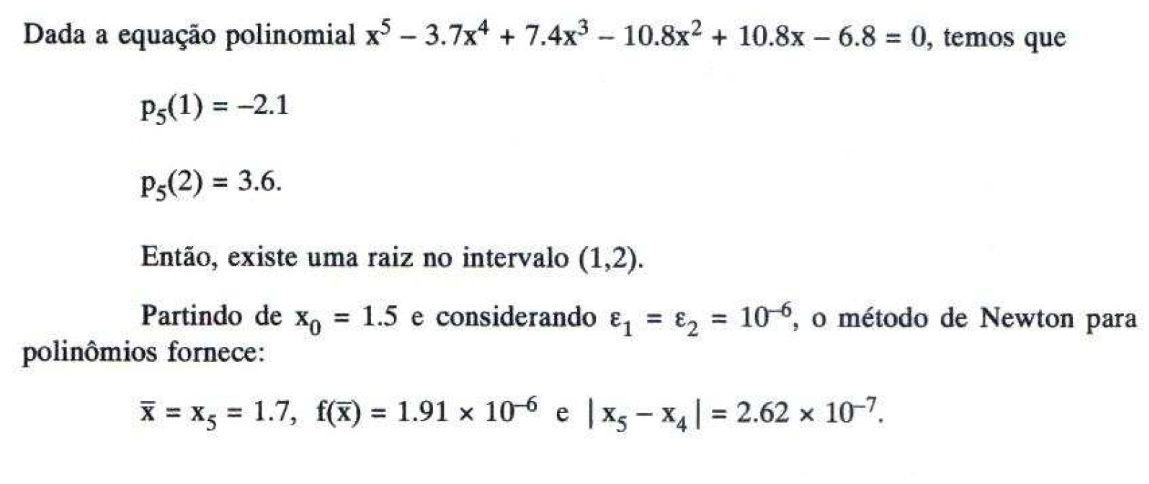

In [45]:
def f(x: float) -> float:
    return x ** 5 - 3.7 * x ** 4 + 7.4 * x ** 3 - 10.8 * x ** 2 + 10.8 * x - 6.8

def phi(x: float) -> float:
    return (-x ** 5 + 3.7 * x ** 4 - 7.4 * x ** 3 + 10.8 * x ** 2 + 6.8) / 10.8

coefficients = (-6.8, 10.8, -10.8, 7.4, -3.7, 1)

x0 = 1.5
epsilon1 = epsilon2 = 10 ** (-6)
it_max = 100

functions = [
    ('Newton', polynomial_newton(coefficients, x0, (epsilon1, epsilon2), it_max)),
    ('Secante', secant_adapted(coefficients, (1, 2), (epsilon1, epsilon2), it_max)),
    ('MPF', fixed_point_method_adapted(coefficients, phi, x0, (epsilon1, epsilon2), it_max))
]

create_table_b(f, functions)

,Newton,Secante,MPF
X aproximado,1.98972,1.7,1.7
Número de Iterações,9,7,13
f(x_aproximado),3.417565867563277,-4.028211542106419e-09,-1.6918950285216283e-06
Tempo Total(ns),12300,17600,19400
Tempo Médio por Iteração(ns),100.0,1842.857143,1261.538462


O método da secante apresentou um melhor resultado em relação ao método de newton, com um menor número de iteração. Mas o método de newton foi o mais rápido, em questão de tempo. 

#### Exemplo 2

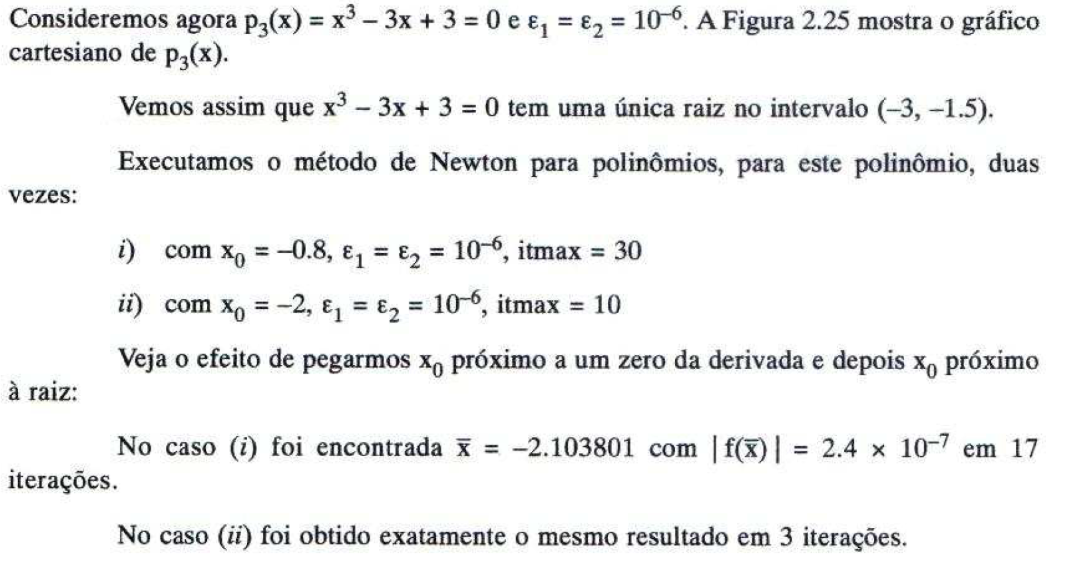

Execução 1:

In [38]:
def f(x: float) -> float:
    return x ** 3 - 3 * x + 3

def phi(x: float) -> float:
    a = 3 * x - 3
    if a < 0:
        return -((-a) ** (1 / 3))
    return a ** (1 / 3)


coefficients = (3, -3, 0, 1)

x0 = -0.8
epsilon1 = epsilon2 = 10 ** (-6)
it_max = 30

functions = [
    ('Newton', polynomial_newton(coefficients, x0, (epsilon1, epsilon2), it_max)),
    ('Secante', secant_adapted(coefficients, (-3, -1), (epsilon1, epsilon2), it_max)),
    ('MPF', fixed_point_method_adapted(coefficients, phi, x0, (epsilon1, epsilon2), it_max))
]

create_table_b(f, functions)

,Newton,Secante,MPF
X aproximado,-0.643275,-2.103803,-2.103803
Número de Iterações,3,8,11
f(x_aproximado),4.66363590566065,2.916696129062757e-08,1.3097155413532846e-06
Tempo Total(ns),7500,18100,12900
Tempo Médio por Iteração(ns),366.666667,1850.0,963.636364


O método de newton apresentou um melhor desempenho, com o menor número de iterações e tempo gasto. Mas apresentou uma raíz discrepante aos demais métodos.

Execução 2:

In [34]:
x0 = -2
epsilon1 = epsilon2 = 10 ** (-6)
it_max = 10

functions = [
    ('Newton', polynomial_newton(coefficients, x0, (epsilon1, epsilon2), it_max)),
    ('Secante', secant_adapted(coefficients, (-3, -1), (epsilon1, epsilon2), it_max)),
    ('MPF', fixed_point_method_adapted(coefficients, phi, x0, (epsilon1, epsilon2), it_max))
]

create_table_b(f, functions)

,Newton,Secante,MPF
X aproximado,-1.936282,-2.103803,-2.103803
Número de Iterações,4,8,9
f(x_aproximado),1.549361116124449,2.916696129062757e-08,1.6609832309555372e-06
Tempo Total(ns),9900,18100,11100
Tempo Médio por Iteração(ns),200.0,1850.0,1011.111111


Novamente, o método de Newton apresentou um melhor desempenho, e dessa vez o X aproximado não foi discrepante.